# Camera 2701: can the image predict Google's drive time beyond the hour of day? (v8: residual model)
Maps each LTA camera frame to Google's drive time, one output per direction (SG→JB, JB→SG). No vehicle counting. Window: 6 Sep 2026 02:00 SGT to the end of 4 Oct 2026.

**Where v7 ended.** Regression on minutes cut the test MAE from 8.9 / 6.3 min (v6 classifier) to 6.9 / 4.9 min (SG→JB / JB→SG), but a time-of-day baseline (median minutes for the same weekend/hour) scored 6.7 / 4.8, and the regression predictions stayed flat for frames with 45+ min of real delay. More backbone fine-tuning changed nothing.

**What this version tests.** The model is told the clock and has to explain only what the clock does not:
- `prediction = time-of-day baseline + network output`, trained on `true minutes − baseline`. The output layer starts at zero, so training starts exactly at the baseline. Training frames use a leave-one-day-out baseline, so the residuals it learns from are as honest as the ones it will meet on new days.
- `resid_image`: the residual comes from the image alone.
- `resid_image_time`: the residual comes from the image plus hour (two harmonics) and weekday features.
- `resid_time_only`: the control. The same residual model with **no image**, only the hour and weekday features. If the image variants beat it, the image is responsible, not a smoother use of the clock.
- `regression_lr0.0001`: v7's best model, trained again here as the reference.

**Design (unchanged from v7 unless stated)**
- Frames: `gs://sg-lta-traffic-cameras/camera_id=2701/month=…` (about one every 10 min). Labels: BigQuery `swiftborder.causeway.travel_times`; rows whose `status` is not OK are dropped. Each frame takes the nearest Google reading within ±5 min.
- Split: consecutive days, 80% train / 20% test; the last 3 training days (`VAL_DAYS`) choose the epoch and the winning variant. Test days are only reported.
- Input: the full frame, ResNet-18 at backbone learning rate 1e-4, loaded once and shared by every variant.
- Metrics: MAE in minutes against the true Google reading, accuracy and ±1 band of the predicted band, confusion matrices (bands 20…100+). Tables show mean ± sd over seeds; paired comparisons use a 95% interval from resampling whole test days, against time of day, the v7 reference, and (for the image variants) the no-image control.
- Section 7 asks whether the model's departure from the baseline points the right way: correlation and slope of (prediction − baseline) against (true − baseline).

**How to read the results**
- Cell 6 prints the validation MAE of time of day alone. A variant is only worth anything if it is below that on validation.
- The decisive test comparisons are `resid_image` / `resid_image_time` against `tod_raw` and against `resid_time_only`. "No clear difference" against both means the image adds nothing measurable.

**Before you run**
- Runtime → Change runtime type → **T4 GPU**. Four variants × 3 seeds is 12 training runs; `resid_time_only` has no CNN and is fast.
- Cell 2 opens a Google sign-in; the account needs access to project `swiftborder`. Read its output (schema, detected columns, direction mapping) and use `G_OVERRIDE` if a guess is wrong.

## 1. Config and helpers

In [9]:
import concurrent.futures as cf
import copy, datetime, gc, math, os, random, re
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from zoneinfo import ZoneInfo

SGT = ZoneInfo("Asia/Singapore")

# --- the two sources -----------------------------------------------------------
GCP_PROJECT = "swiftborder"
BUCKET      = "sg-lta-traffic-cameras"
CAMERA_ID   = "2701"
BQ_TABLE    = "swiftborder.causeway.travel_times"
FRAMES_DIR  = "/content/frames_2701"
OUT_DIR     = "/content"                              # models and csv files are written here

# --- study window (Singapore time): 6 Sep 2026 02:00 to the end of 4 Oct 2026 -----
WINDOW_START = datetime.datetime(2026, 9, 6, 2, 0, 0)
WINDOW_END   = datetime.datetime(2026, 10, 4, 23, 59, 59)

# Timezone of the raw timestamps. If the inspect cell shows they are UTC, set ZoneInfo("UTC").
FILENAME_TZ    = SGT     # timestamp inside the image object names
BQ_DATETIME_TZ = SGT     # only used if the BigQuery time column is a DATETIME/string (no timezone)

# --- duration classes: 20, 30, ... 90, 100+ minutes -----------------------------------------
BAND_MINUTES = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100], dtype=float)   # class centres; the last is "100+"
N_BANDS = len(BAND_MINUTES)
BAND_EDGES = (BAND_MINUTES[:-1] + BAND_MINUTES[1:]) / 2                       # 25, 35, ... 95
BAND_LABELS = ["<25"] + [f"{int(a)}-<{int(b)}" for a, b in zip(BAND_EDGES[:-1], BAND_EDGES[1:])] + ["95+"]
BAND_NAMES = [str(int(m)) for m in BAND_MINUTES[:-1]] + ["100+"]
CENTRES = BAND_MINUTES                                                        # softmax probabilities -> expected minutes

def minutes_to_band(m):
    """Class of a Google duration in minutes: the nearest centre (<25 -> 20 ... 95+ -> 100+). -1 = no label."""
    if m is None or pd.isna(m):
        return -1
    return int(np.digitize(float(m), BAND_EDGES))

# --- alignment, split, training settings -----------------------------------------------
ALIGN_MODE, ALIGN_TOL_MIN = "nearest", 5      # "nearest" reading within 5 min, or "mean" of readings within 5 min
TEST_FRAC, VAL_DAYS = 0.20, 3                 # last 20% of days = test; last VAL_DAYS of the rest pick the epoch
EPOCHS, BATCH = 12, 32
LR_BACKBONE, LR_HEAD, WEIGHT_DECAY = 3e-5, 3e-4, 1e-2
LABEL_SMOOTH, DROPOUT = 0.1, 0.5
EVALS_PER_EPOCH, PATIENCE = 2, 4              # validate twice an epoch; stop after 4 validations without a better val MAE
SEEDS = (0, 1, 2)                             # every variant is trained once per seed -> mean +/- sd

DIRS = (("SG->JB", "sg_jb_min", "sg_jb_band"), ("JB->SG", "jb_sg_min", "jb_sg_band"))

# --- image object names -> Singapore time -----------------------------------------------
TS_PATTERNS = [re.compile(r"(\d{4})(\d{2})(\d{2})[T_-]?(\d{2})(\d{2})(\d{2})"),
               re.compile(r"(\d{4})-(\d{2})-(\d{2})[T_ ](\d{2})[:.\-]?(\d{2})[:.\-]?(\d{2})")]

def parse_frame_ts(name):
    base = os.path.basename(name)
    for pat in TS_PATTERNS:
        m = pat.search(base)
        if m:
            try:
                t = datetime.datetime(*map(int, m.groups()))
            except ValueError:
                continue
            return t.replace(tzinfo=FILENAME_TZ).astimezone(SGT).replace(tzinfo=None)
    return None

# --- BigQuery table -> long frame [ts, direction, minutes] -------------------------------
SG_TOK = {"sg", "sgp", "singapore", "woodlands", "mandai"}
JB_TOK = {"jb", "jbcq", "johor", "my", "mys", "malaysia", "bangunan", "sultan", "ciq"}
NUMERIC = {"INTEGER", "INT64", "FLOAT", "FLOAT64", "NUMERIC", "BIGNUMERIC"}
DIR_NAME_PRIORITY = (r"^direction$", r"direction", r"route_id|route", r"leg|path|segment", r"label|name")
STATUS_OK = {"OK", "SUCCESS"}

def canon_direction(label):
    """'SG_JB' (Singapore -> Johor), 'JB_SG', or None. Whole words are matched; the side named first is the origin
    (SG_TO_MY, mandai_to_shell_jb -> SG_JB; MY_TO_SG, jb_to_woodlands -> JB_SG)."""
    s = str(label).lower()
    words = re.split(r"[^a-z0-9]+", s)
    first = lambda toks: next((i for i, w in enumerate(words) if w in toks), -1)
    sg, jb = first(SG_TOK), first(JB_TOK)
    if sg >= 0 and jb >= 0 and sg != jb:
        return "SG_JB" if sg < jb else "JB_SG"
    if re.search(r"northbound|to[_\- >]*(jb|johor|malaysia)|->\s*(jb|johor)", s):
        return "SG_JB"
    if re.search(r"southbound|to[_\- >]*(sg|singapore|woodlands)|->\s*(sg|singapore)", s):
        return "JB_SG"
    return None

def pick_dir_col(values):
    """values: {STRING column: its distinct values}. The column whose values name both directions; a column called
    'direction' beats 'route_id' beats 'route_name', and a column with fewer distinct values beats one with more."""
    rank = lambda n: next((i for i, p in enumerate(DIR_NAME_PRIORITY) if re.search(p, n, re.I)), len(DIR_NAME_PRIORITY))
    ok = [n for n, vs in values.items() if {canon_direction(v) for v in vs} >= {"SG_JB", "JB_SG"}]
    return min(ok, key=lambda n: (rank(n), len(values[n]))) if ok else None

def guess_google_columns(schema):
    """schema: [(column, bigquery_type)]. Returns the columns to use; override any of them in G_OVERRIDE."""
    ts = [n for n, t in schema if t in ("TIMESTAMP", "DATETIME")]
    ts_col = next((n for n in ts if re.search(r"time|ts|collect|fetch|query|record|creat|observ", n, re.I)),
                  ts[0] if ts else None)
    dur = [n for n, t in schema if t in NUMERIC and re.search(r"duration|travel|minute|second|min|sec", n, re.I)]
    best = lambda cols: next((n for n in cols if "traffic" in n.lower()), cols[0] if cols else None)
    status_col = next((n for n, t in schema if t == "STRING" and re.fullmatch(r"(.*_)?status", n, re.I)), None)
    rank = lambda n: next((i for i, p in enumerate(DIR_NAME_PRIORITY) if re.search(p, n, re.I)), None)
    dir_cands = sorted([n for n, t in schema if t == "STRING" and n != status_col and rank(n) is not None], key=rank)
    dir_col = dir_cands[0] if dir_cands else None
    od = [next((n for n, t in schema if t == "STRING" and re.search(p, n, re.I)), None)
          for p in ("origin|from", "destination|dest|to$")]
    wide = {}
    for n in dur:                                  # one duration column per direction, e.g. sg_to_jb_duration_s
        d = canon_direction(n)
        if d and (d not in wide or ("traffic" in n.lower() and "traffic" not in wide[d].lower())):
            wide[d] = n
    layout = "long" if dir_col else "wide" if wide else "od" if all(od) else None
    return dict(layout=layout, ts_col=ts_col, dir_col=dir_col, od_cols=od if all(od) else None,
                duration_col=best(dur), wide=wide, status_col=status_col, unit=None, direction_map=None)

def to_minutes(series, name, unit=None):
    s = pd.to_numeric(series, errors="coerce")
    if unit is None:
        n = name.lower()
        unit = "s" if re.search(r"sec|_s$|_secs$", n) else "min" if re.search(r"min", n) else ("s" if s.median() > 400 else "min")
    return s / 60.0 if unit == "s" else s

def normalize_google(df, cols):
    """Raw BigQuery rows -> long frame [ts (Singapore time), direction (SG_JB / JB_SG), minutes]."""
    if not cols.get("layout") or not cols.get("ts_col"):
        raise ValueError(f"Couldn't detect the table layout ({cols}). Set G_OVERRIDE with layout "
                         "('long' | 'wide' | 'od'), ts_col, duration_col and dir_col (or wide / od_cols).")
    sc = cols.get("status_col")
    if sc and sc in df:                                   # failed lookups must not become labels
        good = df[sc].astype(str).str.strip().str.upper().isin(STATUS_OK)
        if not good.any():
            print(f"status filter skipped: no value of '{sc}' looks like OK ({df[sc].unique()[:5].tolist()})")
        elif not good.all():
            print(f"status filter: dropped {int((~good).sum())} of {len(df)} rows where '{sc}' is not OK")
            df = df[good]
    ts = pd.to_datetime(df[cols["ts_col"]])
    if ts.dt.tz is None:
        ts = ts.dt.tz_localize(BQ_DATETIME_TZ)
    ts = ts.dt.tz_convert(SGT).dt.tz_localize(None)
    if cols["layout"] in ("long", "od"):
        raw = (df[cols["dir_col"]] if cols["layout"] == "long"
               else df[cols["od_cols"][0]].astype(str) + " -> " + df[cols["od_cols"][1]].astype(str))
        dmap = {v: canon_direction(v) for v in raw.dropna().unique()}
        dmap.update(cols.get("direction_map") or {})
        unknown = [v for v, d in dmap.items() if d is None and v not in (cols.get("direction_map") or {})]
        if unknown:
            raise ValueError(f"Can't tell which way these values go: {unknown[:8]}. Set "
                             "G_OVERRIDE['direction_map'] = {value: 'SG_JB' | 'JB_SG' | None} (None drops the rows).")
        out = pd.DataFrame(dict(ts=ts, direction=raw.map(dmap),
                                minutes=to_minutes(df[cols["duration_col"]], cols["duration_col"], cols.get("unit"))))
    else:
        out = pd.concat([pd.DataFrame(dict(ts=ts, direction=d, minutes=to_minutes(df[c], c, cols.get("unit"))))
                         for d, c in cols["wide"].items()], ignore_index=True)
    out = out.dropna(subset=["ts", "direction", "minutes"])
    out = out[out["minutes"] > 0]
    return out.groupby(["ts", "direction"], as_index=False)["minutes"].median().sort_values("ts").reset_index(drop=True)

# --- Google 5-min readings -> the 10-min frames ------------------------------------------
def align_labels(frames, g, direction, mode=ALIGN_MODE, tol_min=ALIGN_TOL_MIN):
    """For every frame, the Google reading for one direction: columns minutes, google_ts, offset_min (Google minus frame
    time, in minutes). NaN where no reading lies within tol_min. 'nearest' = closest reading; 'mean' = average of all."""
    gd = g[g["direction"] == direction].sort_values("ts")
    out = pd.DataFrame({"minutes": np.nan, "google_ts": pd.NaT, "offset_min": np.nan}, index=frames.index)
    if gd.empty:
        return out
    if mode == "nearest":
        left = frames[["ts"]].assign(i=frames.index).astype({"ts": "datetime64[ns]"}).sort_values("ts")
        right = gd.assign(google_ts=gd["ts"]).astype({"ts": "datetime64[ns]"})[["ts", "google_ts", "minutes"]]
        m = pd.merge_asof(left, right, on="ts", direction="nearest", tolerance=pd.Timedelta(minutes=tol_min)).set_index("i")
        out.loc[m.index, "minutes"] = m["minutes"]
        out.loc[m.index, "google_ts"] = m["google_ts"]
    elif mode == "mean":
        gts, mins = gd["ts"].to_numpy("datetime64[ns]"), gd["minutes"].to_numpy()
        tol = np.timedelta64(int(tol_min * 60e9), "ns")
        for i, t in zip(frames.index, frames["ts"].to_numpy("datetime64[ns]")):
            lo, hi = np.searchsorted(gts, t - tol, "left"), np.searchsorted(gts, t + tol, "right")
            if hi > lo:
                out.loc[i, "minutes"] = mins[lo:hi].mean()
                out.loc[i, "google_ts"] = pd.Timestamp(int(gts[lo:hi].astype("int64").mean()))
    else:
        raise ValueError(f"Unknown ALIGN_MODE={mode!r}. Use 'nearest' or 'mean'.")
    out["offset_min"] = (out["google_ts"] - frames["ts"]).dt.total_seconds() / 60.0
    return out

def split_by_days(df, test_frac=TEST_FRAC, val_days=VAL_DAYS):
    """Consecutive days: first (1 - test_frac) of the days train, the rest test; the last val_days of train pick the epoch."""
    days = sorted(df["ts"].dt.date.unique())
    n_test = max(1, round(test_frac * len(days)))
    train_days, test_days = days[:-n_test], days[-n_test:]
    val = train_days[-val_days:] if val_days and len(train_days) > val_days + 3 else []
    fit = [d for d in train_days if d not in val]
    pick = lambda ds: df[df["ts"].dt.date.isin(ds)]
    return pick(fit), pick(val), pick(test_days), (fit, val, test_days)


## 2. Connect and inspect both sources
Lists the frames in the window and shows the BigQuery schema, a few rows, and the detected columns. The direction column is chosen by checking its actual values, not just its name.

In [2]:
try:
    from google.colab import auth
    print("Requesting Google Authentication...")
    auth.authenticate_user()
    print("Authentication successful!")
except Exception as e:
    print(f"Authentication failed: {e}")
    print("Please ensure you allow the pop-up and grant the requested permissions, then try running this cell again.")

from google.cloud import bigquery, storage

gcs = storage.Client(project=GCP_PROJECT)
bq = bigquery.Client(project=GCP_PROJECT)

def list_frames():
    """Image objects for CAMERA_ID whose timestamp falls inside the window."""
    pad = datetime.timedelta(days=1)
    months, d = [], WINDOW_START - pad
    while d <= WINDOW_END + pad:
        months.append(d.strftime("%Y-%m")); d += datetime.timedelta(days=1)
    rows, raw = [], []
    for mo in sorted(set(months)):
        for b in gcs.list_blobs(BUCKET, prefix=f"camera_id={CAMERA_ID}/month={mo}/"):
            if not b.name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            raw.append(b.name)
            t = parse_frame_ts(b.name)
            if t is not None and WINDOW_START <= t <= WINDOW_END:
                rows.append(dict(blob=b.name, ts=t))
    if not rows:
        raise RuntimeError(f"No frames in the window. Example object names: {raw[:5]}")
    return pd.DataFrame(rows).drop_duplicates("ts").sort_values("ts").reset_index(drop=True)

try:
    frames_all = list_frames()
    gap = frames_all["ts"].diff().dt.total_seconds().div(60)
    print(f"{len(frames_all)} frames, {frames_all['ts'].min()} -> {frames_all['ts'].max()} (Singapore time)")
    print(f"minutes between frames: median {gap.median():.1f}, max {gap.max():.0f} | frames per day (min/median/max):",
          frames_all.groupby(frames_all['ts'].dt.date).size().agg(['min', 'median', 'max']).tolist())
    print("example object:", frames_all["blob"].iloc[0])

    table = bq.get_table(BQ_TABLE)
    schema = [(f.name, f.field_type) for f in table.schema]
    print(f"\n{BQ_TABLE}: {table.num_rows} rows")
    print(pd.DataFrame(schema, columns=["column", "type"]).to_string(index=False))
    print(bq.query(f"SELECT * FROM `{BQ_TABLE}` LIMIT 5").to_dataframe().to_string())

    guess = guess_google_columns(schema)
    # Confirm the direction column against the data: the STRING column whose values name both directions.
    values = {n: bq.query(f"SELECT DISTINCT `{n}` AS v FROM `{BQ_TABLE}` WHERE `{n}` IS NOT NULL LIMIT 50").to_dataframe()["v"].tolist()
              for n, t in schema if t == "STRING"}
    chosen = pick_dir_col(values)
    if chosen:
        guess.update(layout="long", dir_col=chosen)
    print("\nauto-detected:", guess)
    print("direction values:", {v: canon_direction(v) for v in values.get(guess["dir_col"], [])})
    print("status values   :", values.get(guess["status_col"]))
except Exception as e:
    print(f"\nCould not complete source inspection due to authorization or client error: {e}")
    raise

# If a guess is wrong, override it here, e.g. G_OVERRIDE = {"duration_col": "duration_in_traffic_sec", "unit": "s"}
G_OVERRIDE = {}


Requesting Google Authentication...
Authentication successful!
4042 frames, 2026-09-06 02:05:50 -> 2026-10-04 23:55:48 (Singapore time)
minutes between frames: median 10.0, max 220 | frames per day (min/median/max): [100.0, 143.0, 144.0]
example object: camera_id=2701/month=2026-09/2701_20260906T020550.jpg

swiftborder.causeway.travel_times: 19880 rows
                 column      type
            observed_at TIMESTAMP
        observed_at_sgt  DATETIME
      observed_date_sgt      DATE
               route_id    STRING
             route_name    STRING
              direction    STRING
                 status    STRING
             origin_lat     FLOAT
             origin_lng     FLOAT
               dest_lat     FLOAT
               dest_lng     FLOAT
             distance_m   INTEGER
           duration_sec   INTEGER
duration_in_traffic_sec   INTEGER
       congestion_ratio     FLOAT
              speed_kmh     FLOAT
          error_message    STRING
                       observed_a

## 3. Download the frames and load the Google durations
Drops rows whose status is not OK and prints how many were removed.

In [3]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True                # tolerate damaged or truncated frames

def download_frames(frames):
    os.makedirs(FRAMES_DIR, exist_ok=True)
    bucket = gcs.bucket(BUCKET)
    def one(row):
        path = os.path.join(FRAMES_DIR, f"{CAMERA_ID}_{row.ts:%Y%m%dT%H%M%S}.jpg")
        try:
            if not os.path.exists(path):
                bucket.blob(row.blob).download_to_filename(path + ".part")
                os.replace(path + ".part", path)
            return path
        except Exception as exc:
            print("  failed:", row.blob, exc)
            return None
    with cf.ThreadPoolExecutor(8) as ex:               # the storage client's connection pool holds 10
        paths = list(tqdm(ex.map(one, frames.itertuples()), total=len(frames)))
    out = frames.assign(path=paths).dropna(subset=["path"]).reset_index(drop=True)
    print(f"{len(out)} of {len(frames)} frames in {FRAMES_DIR}")
    return out

def load_google():
    cols = {**guess, **G_OVERRIDE}
    pad = datetime.timedelta(days=1)
    lo, hi = WINDOW_START - pad, WINDOW_END + pad
    ts_type = dict(schema)[cols["ts_col"]]
    if ts_type == "TIMESTAMP":
        utc = lambda t: t.replace(tzinfo=SGT).astimezone(datetime.timezone.utc)
        params = [bigquery.ScalarQueryParameter("lo", "TIMESTAMP", utc(lo)), bigquery.ScalarQueryParameter("hi", "TIMESTAMP", utc(hi))]
    elif ts_type == "DATETIME":
        loc = lambda t: t.replace(tzinfo=SGT).astimezone(BQ_DATETIME_TZ).replace(tzinfo=None)
        params = [bigquery.ScalarQueryParameter("lo", "DATETIME", loc(lo)), bigquery.ScalarQueryParameter("hi", "DATETIME", loc(hi))]
    else:
        params = None
    sql = f"SELECT * FROM `{BQ_TABLE}`" + (f" WHERE `{cols['ts_col']}` >= @lo AND `{cols['ts_col']}` < @hi" if params else "")
    raw = bq.query(sql, job_config=bigquery.QueryJobConfig(query_parameters=params or [])).to_dataframe()
    g = normalize_google(raw, cols)
    g = g[(g["ts"] >= lo) & (g["ts"] <= hi)]
    print(f"{len(g)} Google readings in the window:",
          g.groupby("direction")["minutes"].describe()[["count", "min", "50%", "max"]].round(1).to_dict("index"))
    return g

frames = download_frames(frames_all)
g = load_google()


  0%|          | 0/4042 [00:00<?, ?it/s]

4042 of 4042 frames in /content/frames_2701
17231 Google readings in the window: {'JB_SG': {'count': 8616.0, 'min': 12.6, '50%': 22.9, 'max': 69.9}, 'SG_JB': {'count': 8615.0, 'min': 10.0, '50%': 23.7, 'max': 67.0}}


## 4. Align, assign bands, split by dates
Each frame takes the Google reading around its timestamp. The split is by whole days (FIT → VAL → TEST). The band table shows the training frames per band; bands are only used for the confusion matrix and band accuracy.

In [4]:
from IPython.display import display

for name, mcol, bcol in DIRS:
    prefix = mcol[:-len("_min")]                                      # sg_jb / jb_sg
    a = align_labels(frames, g, prefix.upper())
    frames[mcol] = a["minutes"]
    frames[f"{prefix}_google_ts"] = a["google_ts"]
    frames[f"{prefix}_align_offset_min"] = a["offset_min"]
    frames[bcol] = frames[mcol].map(minutes_to_band)

# Keep frames that have a Google reading in both directions.
df = frames.dropna(subset=[m for _, m, _ in DIRS]).sort_values("ts").reset_index(drop=True)
print(f"Usable aligned images: {len(df):,} of {len(frames):,}")
for name, mcol, _ in DIRS:
    off = df[mcol[:-len("_min")] + "_align_offset_min"].abs()
    print(f"{name}: |offset| mean {off.mean():.2f} min, median {off.median():.2f}, max {off.max():.2f}")
print("\nSample alignment:")
display(df[["ts", "sg_jb_google_ts", "sg_jb_align_offset_min", "sg_jb_min", "jb_sg_google_ts", "jb_sg_align_offset_min", "jb_sg_min"]].head(10))

# Chronological split by whole days: FIT -> VAL (picks the epoch) -> TEST.
fit_df, val_df, test_df, (fit_days, val_days, test_days) = split_by_days(df)
span = lambda ds: f"{ds[0]} -> {ds[-1]} ({len(ds)} days)" if ds else "none"
print(f"\nFIT : {span(fit_days)}, {len(fit_df):,} images\nVAL : {span(val_days)}, {len(val_df):,} images"
      f"\nTEST: {span(test_days)}, {len(test_df):,} images")
assert fit_df["ts"].max() < val_df["ts"].min() < test_df["ts"].min() if len(val_df) else fit_df["ts"].max() < test_df["ts"].min()

# Class counts on the training days (the bands are only used for the confusion matrix and the band accuracy).
counts_by_dir = []
for name, mcol, bcol in DIRS:
    counts = np.bincount(fit_df.loc[fit_df[bcol] >= 0, bcol], minlength=N_BANDS)
    print(f"\n{name} training days: {fit_df[mcol].min():.0f} / {fit_df[mcol].median():.0f} / {fit_df[mcol].max():.0f} min (min / median / max)")
    display(pd.DataFrame({"band": BAND_LABELS, "minutes": BAND_NAMES, "count": counts, "percent": counts / counts.sum() * 100}).round(2))
    empty = [l for l, n in zip(BAND_LABELS, counts) if n == 0]
    if empty:
        print(f"WARNING: no training examples for bands {empty}; a band classifier could never predict them.")


Usable aligned images: 4,042 of 4,042
SG->JB: |offset| mean 0.70 min, median 0.69, max 3.96
JB->SG: |offset| mean 0.70 min, median 0.69, max 2.25

Sample alignment:


,ts,sg_jb_google_ts,sg_jb_align_offset_min,sg_jb_min,jb_sg_google_ts,jb_sg_align_offset_min,jb_sg_min
0,2026-09-06 02:05:50,2026-09-06 02:05:00.834,-0.819433,13.716667,2026-09-06 02:05:00.834,-0.819433,18.350000
1,2026-09-06 02:15:51,2026-09-06 02:15:04.389,-0.776850,12.666667,2026-09-06 02:15:04.389,-0.776850,17.416667
2,2026-09-06 02:25:31,2026-09-06 02:25:04.264,-0.445600,12.066667,2026-09-06 02:25:04.264,-0.445600,17.900000
3,2026-09-06 02:35:31,2026-09-06 02:35:04.127,-0.447883,12.283333,2026-09-06 02:35:04.127,-0.447883,17.050000
4,2026-09-06 02:45:52,2026-09-06 02:45:03.898,-0.801700,11.750000,2026-09-06 02:45:03.898,-0.801700,16.783333
5,2026-09-06 02:55:52,2026-09-06 02:55:04.162,-0.797300,11.650000,2026-09-06 02:55:04.162,-0.797300,16.516667
6,2026-09-06 03:05:32,2026-09-06 03:05:03.599,-0.473350,11.583333,2026-09-06 03:05:03.599,-0.473350,16.916667
7,2026-09-06 03:15:53,2026-09-06 03:15:04.224,-0.812933,11.950000,2026-09-06 03:15:04.224,-0.812933,17.216667
8,2026-09-06 03:25:33,2026-09-06 03:25:03.593,-0.490117,11.616667,2026-09-06 03:25:03.593,-0.490117,17.783333
9,2026-09-06 03:35:34,2026-09-06 03:35:03.969,-0.500517,11.550000,2026-09-06 03:35:03.969,-0.500517,18.250000



FIT : 2026-09-06 -> 2026-09-25 (20 days), 2,770 images
VAL : 2026-09-26 -> 2026-09-28 (3 days), 431 images
TEST: 2026-09-29 -> 2026-10-04 (6 days), 841 images

SG->JB training days: 11 / 23 / 59 min (min / median / max)


,band,minutes,count,percent
0,<25,20,1516,54.73
1,25-<35,30,670,24.19
2,35-<45,40,431,15.56
3,45-<55,50,137,4.95
4,55-<65,60,16,0.58
5,65-<75,70,0,0.00
6,75-<85,80,0,0.00
7,85-<95,90,0,0.00
8,95+,100+,0,0.00



JB->SG training days: 13 / 22 / 70 min (min / median / max)


,band,minutes,count,percent
0,<25,20,1662,60.00
1,25-<35,30,556,20.07
2,35-<45,40,320,11.55
3,45-<55,50,173,6.25
4,55-<65,60,54,1.95
5,65-<75,70,5,0.18
6,75-<85,80,0,0.00
7,85-<95,90,0,0.00
8,95+,100+,0,0.00


## 5. Model, residual target, training, evaluation
The network is the v7 one (CNN → BiGRU → one head per direction) with optional time features and an optional image branch. `residual` adds the time-of-day baseline to the output; `loo_tod_minutes` builds the leave-one-day-out baseline for the training frames.

In [5]:
import torch.nn as nn, torch.nn.functional as F
from PIL import Image, ImageDraw, ImageOps
from torchvision import models

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

ROAD_CROP = (0.34, 0.27, 1.00, 1.00)                  # left, top, right, bottom as fractions: just the causeway
CORRIDOR = [(0.340, 0.865), (1.000, 0.2753), (1.000, 0.3935), (0.386, 1.000), (0.340, 1.000)]   # 2026 road polygon
MEAN_RGB = (124, 116, 104)

def load_frame(path, crop=None, mask=False, equalize=False, grayscale=False, size=(288, 448)):
    """One frame -> uint8 (H, W, 3): crop, (equalise luminance), (grey out everything off the road), (grayscale), resize.
    Grayscale is repeated into 3 identical channels because the pretrained backbones expect RGB."""
    img = Image.open(path).convert("RGB")
    W0, H0 = img.size
    l, t, r, b = crop or (0, 0, 1, 1)                 # crop and CORRIDOR are fractions of the full frame
    img = img.crop((int(l * W0), int(t * H0), int(r * W0), int(b * H0)))
    W, H = img.size
    if equalize:
        y, cb, cr = img.convert("YCbCr").split()
        img = Image.merge("YCbCr", (ImageOps.equalize(y), cb, cr)).convert("RGB")
    if mask:
        m = Image.new("L", img.size, 0)
        ImageDraw.Draw(m).polygon([((x - l) / (r - l) * W, (y - t) / (b - t) * H) for x, y in CORRIDOR], fill=255)
        img = Image.composite(img, Image.new("RGB", img.size, MEAN_RGB), m)
    if grayscale:
        gray = img.convert("L")
        img = Image.merge("RGB", (gray, gray, gray))
    return np.asarray(img.resize((size[1], size[0]), Image.BILINEAR), dtype=np.uint8)

def build_cache(paths, cfg):
    """All frames of one variant as a uint8 tensor (N, H, W, 3)."""
    fn = lambda p: load_frame(p, cfg["crop"], cfg["mask"], cfg["equalize"], cfg["grayscale"], cfg["size"])
    X = np.empty((len(paths), *cfg["size"], 3), np.uint8)
    with cf.ThreadPoolExecutor(8) as ex:
        for i, arr in enumerate(tqdm(ex.map(fn, paths), total=len(paths), desc="Loading images")):
            X[i] = arr
    return torch.from_numpy(X)

# Sanity check of the grayscale filter on the first frame.
_g = load_frame(frames.iloc[0]["path"], crop=ROAD_CROP, grayscale=True)
assert np.array_equal(_g[..., 0], _g[..., 1]) and np.array_equal(_g[..., 1], _g[..., 2]), "grayscale: R, G, B differ"

def make_backbone(name):
    if name == "resnet18":
        return nn.Sequential(*list(models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).children())[:-2])
    if name == "efficientnet_b0":
        return models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1).features
    raise ValueError(name)

# --- what the network is trained to output -------------------------------------------------------------------------
#   regression  the Google minutes directly (v7)
#   residual    the Google minutes minus the time-of-day baseline for that frame: prediction = baseline + network output.
#               The head starts at zero, so training starts exactly at the time-of-day baseline and the image can only help
#               by explaining what the hour and weekday do not.
LOSSES = ("regression", "residual")
REG_SCALE = 10.0                                      # the head works in tens of minutes
TIME_DIM = 11                                         # sin/cos of the hour (2 harmonics) + weekday one-hot

def time_features(ts):
    """Hour of day (2 harmonics) and weekday one-hot, one row per timestamp."""
    h = (ts.dt.hour + ts.dt.minute / 60.0).values
    cols = [np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24), np.sin(4 * np.pi * h / 24), np.cos(4 * np.pi * h / 24)]
    cols += [(ts.dt.dayofweek.values == k).astype(float) for k in range(7)]
    return torch.tensor(np.stack(cols, 1), dtype=torch.float32)

class CNNRNN(nn.Module):
    """CNN feature map -> BiGRU scanning the image left to right (columns follow distance along the diagonal
    causeway; height stays inside each step so the two carriageways stay separable) -> one head per direction.
    use_time: the hour / weekday features are also given to the head (through a small layer).
    use_image=False drops the CNN and the GRU entirely (a time-features-only control).
    freeze = number of leading backbone modules to keep fixed (0 = train everything)."""
    def __init__(self, backbone, size, loss="regression", hidden=128, freeze=0, init_minutes=(25.0, 25.0), use_time=False, use_image=True):
        super().__init__()
        self.freeze, self.use_time, self.use_image = freeze, use_time, use_image
        dim = 0
        if use_image:
            self.cnn = make_backbone(backbone)
            was = self.cnn.training
            self.cnn.eval()
            with torch.no_grad():
                c, h = self.cnn(torch.zeros(1, 3, *size)).shape[1:3]
            self.cnn.train(was)
            for m in list(self.cnn)[:freeze]:
                for p in m.parameters():
                    p.requires_grad = False
            self.reduce = nn.Sequential(nn.Conv2d(c, 64, 1), nn.ReLU())
            self.rnn = nn.GRU(64 * h, hidden, batch_first=True, bidirectional=True)
            self.drop = nn.Dropout(DROPOUT)
            dim += 2 * hidden
        if use_time:
            self.tmlp = nn.Sequential(nn.Linear(TIME_DIM, 32), nn.ReLU())
            dim += 32
        self.heads = nn.ModuleList([nn.Linear(dim, 1) for _ in range(2)])
        for head, m in zip(self.heads, init_minutes):
            if loss == "residual":                    # start exactly at the baseline
                nn.init.zeros_(head.weight); nn.init.zeros_(head.bias)
            else:                                     # start at the training-days mean
                head.bias.data.fill_(float(m) / REG_SCALE)
    def train(self, mode=True):
        super().train(mode)
        if self.use_image:
            for m in list(self.cnn)[:self.freeze]:
                m.eval()
        return self
    def forward(self, x, tf):
        parts = []
        if self.use_image:
            f = self.reduce(self.cnn(x))
            B, C, h, w = f.shape
            seq, _ = self.rnn(f.permute(0, 3, 1, 2).reshape(B, w, C * h))
            parts.append(self.drop(seq.mean(dim=1)))
        if self.use_time:
            parts.append(self.tmlp(tf))
        z = torch.cat(parts, 1)
        return [head(z) for head in self.heads]                     # [SG->JB, JB->SG], shape (n, 1) each

_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
_STD = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

def prep(xb, train):
    """uint8 NHWC batch -> normalised NCHW on the GPU. Training: brightness/contrast jitter, a small shift, and a random
    90-100% crop rescaled back (never a horizontal flip: it would mirror the road and swap the directions)."""
    x = xb.to(DEVICE).permute(0, 3, 1, 2).float() / 255
    if train:
        b, _, H, W = x.shape
        x = x * (1 + (torch.rand(b, 1, 1, 1, device=DEVICE) - 0.5) * 0.4) + (torch.rand(b, 1, 1, 1, device=DEVICE) - 0.5) * 0.2
        x = torch.roll(x, shifts=(random.randint(-6, 6), random.randint(-6, 6)), dims=(2, 3))
        sc = random.uniform(0.9, 1.0)
        h, w = int(H * sc), int(W * sc)
        top, left = random.randint(0, H - h), random.randint(0, W - w)
        x = F.interpolate(x[:, :, top:top + h, left:left + w], size=(H, W), mode="bilinear", align_corners=False)
    return (x.clamp(0, 1) - _MEAN) / _STD

def head_loss(out, minutes, base, loss):
    """Smooth L1 (~ L1, smooth within +-1 minute) on the minutes, or on the minutes minus the baseline for 'residual'."""
    target = (minutes - base) if loss == "residual" else minutes
    return F.smooth_l1_loss(out.squeeze(1), target / REG_SCALE, beta=0.1)

def decode(out, loss, base):
    """Head output (n, 1) and baseline minutes (n,) -> dict(minutes, band, probs)."""
    m = out.squeeze(1).numpy().astype(float) * REG_SCALE
    if loss == "residual":
        m = m + base
    return dict(minutes=m, band=np.digitize(m, BAND_EDGES), probs=None)

def batch(D, idx, train):
    """One batch of model inputs and targets; D holds X (frames), Y (band ids), T (Google minutes), TF (time features), B (baseline)."""
    bi = torch.as_tensor(idx)
    x = prep(D["X"][bi], train) if D["use_image"] else None
    return x, D["TF"][bi].to(DEVICE), D["Y"][bi].to(DEVICE), D["T"][bi].to(DEVICE), D["B"][bi].to(DEVICE)

def run_epoch(model, D, idx, loss, opt=None, sched=None):
    """One pass over idx; trains when opt is given."""
    train = opt is not None
    model.train(train)
    order = np.random.permutation(idx) if train else np.asarray(idx)
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for s in range(0, len(order), BATCH):
            x, tf, y, t, base = batch(D, order[s:s + BATCH], train)
            batch_loss = None
            for d, out in enumerate(model(x, tf)):
                ok = y[:, d] >= 0                                   # skip an unlabelled direction
                if ok.any():
                    l = head_loss(out[ok], t[ok, d], base[ok, d], loss)
                    batch_loss = l if batch_loss is None else batch_loss + l
            if batch_loss is None:
                continue
            if train:
                opt.zero_grad(); batch_loss.backward(); opt.step()
                if sched is not None:
                    sched.step()
            total += batch_loss.item() * len(y); n += len(y)
    return total / max(n, 1)

@torch.no_grad()
def predict(model, D, idx, loss):
    """Per direction: dict(minutes, band, probs=None) for the frames idx."""
    model.eval()
    outs = [[], []]
    for s in range(0, len(idx), BATCH):
        x, tf, _, _, _ = batch(D, np.asarray(idx[s:s + BATCH]), False)
        for d, o in enumerate(model(x, tf)):
            outs[d].append(o.float().cpu())
    return [decode(torch.cat(o), loss, D["B"][torch.as_tensor(np.asarray(idx)), d].numpy().astype(float)) for d, o in enumerate(outs)]

def val_mae(pred, M):
    """Mean over the two directions of |predicted minutes - true Google minutes|; NaN (no reading) rows are skipped."""
    return float(np.mean([np.nanmean(np.abs(pred[d]["minutes"] - M[:, d])) for d in range(2)]))

def fit(cfg, D, M, fit_idx, val_idx, seed, tag):
    """Train for up to EPOCHS epochs, validating EVALS_PER_EPOCH times per epoch. The weights kept are those with the
    lowest validation MAE in minutes; training stops after PATIENCE validations without improvement."""
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    loss = cfg["loss"]
    model = CNNRNN(cfg["backbone"], cfg["size"], loss, freeze=cfg["freeze"], init_minutes=np.nanmean(M[fit_idx], axis=0),
                   use_time=cfg["use_time"], use_image=cfg["use_image"]).to(DEVICE)
    head = [p for n, p in model.named_parameters() if not n.startswith("cnn.")]
    groups = [{"params": head, "lr": LR_HEAD}]
    if cfg["use_image"]:
        groups.append({"params": [p for p in model.cnn.parameters() if p.requires_grad], "lr": cfg["lr_backbone"]})
    opt = torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)
    steps = EPOCHS * sum(math.ceil(len(c) / BATCH) for c in np.array_split(fit_idx, EVALS_PER_EPOCH))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps)
    best, state, bad = float("inf"), copy.deepcopy(model.state_dict()), 0
    for ep in range(1, EPOCHS + 1):
        for k, chunk in enumerate(np.array_split(np.random.permutation(fit_idx), EVALS_PER_EPOCH), 1):
            tr = run_epoch(model, D, chunk, loss, opt, sched)
            if len(val_idx) == 0:                                   # no validation days: keep the last weights
                state = copy.deepcopy(model.state_dict())
                continue
            va = val_mae(predict(model, D, val_idx, loss), M[val_idx])
            improved = va < best - 1e-9
            if improved:
                best, state, bad = va, copy.deepcopy(model.state_dict()), 0
            else:
                bad += 1
            print(f"[{tag} s{seed}] epoch {ep + (k - 1) / EVALS_PER_EPOCH:4.1f}  train {tr:.3f}  val MAE {va:.2f} min" + ("  *" if improved else ""))
            if bad >= PATIENCE:
                break
        if bad >= PATIENCE:
            break
    model.load_state_dict(state)
    return model

def tod_minutes(df_fit, df_eval, col):
    """Time-of-day-only baseline: median training minutes for the same (weekend?, hour). No image involved."""
    key = lambda d: list(zip(d["ts"].dt.dayofweek >= 5, d["ts"].dt.hour))
    med = df_fit.assign(k=key(df_fit)).groupby("k")[col].median().to_dict()
    default = df_fit[col].median()
    return np.array([med[k] if not pd.isna(med.get(k, np.nan)) else default for k in key(df_eval)])

def loo_tod_minutes(df_fit, col):
    """The same baseline for the training frames, each day computed WITHOUT that day. The residuals the model learns from are
    then as honest as the ones it will meet on new days (the in-sample medians would make them look too small)."""
    day = df_fit["ts"].dt.date.values
    out = np.full(len(df_fit), np.nan)
    for d in np.unique(day):
        m = day == d
        out[m] = tod_minutes(df_fit[~m], df_fit[m], col)
    return out
def evaluate(pred, df_eval, df_fit, tag, seed):
    """Accuracy and within-one-band accuracy of the predicted band, and MAE in minutes against the true Google minutes:
    mae_min = the model's minutes (expected value / regression output), mae_band = the predicted band's centre.
    References: majority band; time of day alone, snapped to a band centre (tod) and as raw median minutes (tod_raw, the
    fair match for a continuous minute estimate); 'oracle' = the true band's centre, the best any band classifier can do."""
    hours = df_eval["ts"].dt.hour.values
    subsets = (("all", np.ones(len(df_eval), bool)), ("day", (hours >= 7) & (hours < 19)), ("night", (hours < 7) | (hours >= 19)))
    rows, errs = [], {}
    for d, (name, mcol, bcol) in enumerate(DIRS):
        pm, pb = pred[d]["minutes"], pred[d]["band"]
        true_min, true_band = df_eval[mcol].values, df_eval[bcol].values
        major = np.bincount(df_fit.loc[df_fit[bcol] >= 0, bcol], minlength=N_BANDS).argmax()
        tod_raw = tod_minutes(df_fit, df_eval, mcol)
        tod_band = np.array([minutes_to_band(m) for m in tod_raw])
        errs[name] = dict(ok=true_band >= 0, model=np.abs(pm - true_min),
                          tod=np.abs(CENTRES[tod_band] - true_min), tod_raw=np.abs(tod_raw - true_min))
        for label, m in subsets:
            ok = (true_band >= 0) & m
            if not ok.any():
                continue
            err = lambda minutes: float(np.mean(np.abs(minutes[ok] - true_min[ok])))
            rows.append(dict(variant=tag, seed=seed, dir=name, subset=label, n=int(ok.sum()),
                             acc=np.mean(pb[ok] == true_band[ok]), within1=np.mean(abs(pb[ok] - true_band[ok]) <= 1),
                             mae_min=err(pm), mae_band=err(CENTRES[pb]),
                             acc_major=np.mean(major == true_band[ok]), mae_major=err(np.full(len(true_min), CENTRES[major])),
                             acc_tod=np.mean(tod_band[ok] == true_band[ok]), mae_tod=err(CENTRES[tod_band]), mae_tod_raw=err(tod_raw),
                             mae_oracle=err(CENTRES[np.where(true_band >= 0, true_band, 0)])))
    return pd.DataFrame(rows), errs

def day_bootstrap(diff, days, n_boot=2000, seed=0):
    """95% interval for mean(diff) when whole days are resampled: frames within a day are far from independent."""
    rng = np.random.default_rng(seed)
    uniq = np.unique(days)
    by_day = {d: diff[days == d] for d in uniq}
    means = [np.concatenate([by_day[d] for d in rng.choice(uniq, len(uniq))]).mean() for _ in range(n_boot)]
    return np.percentile(means, [2.5, 97.5])

def compare(diff, days, better, **ids):
    """One row of a paired comparison; diff = error of the first model minus error of the second (negative = first better)."""
    lo, hi = day_bootstrap(diff, days)
    per_day = pd.Series(diff).groupby(days).mean()
    return dict(**ids, mae_difference=diff.mean(), ci95_lo=lo, ci95_hi=hi, days_better=f"{(per_day < 0).sum()}/{len(per_day)}",
                verdict=f"{better} better" if hi < 0 else f"{better} worse" if lo > 0 else "no clear difference")

def confusion(bands, df_eval, d):
    """Counts of (true band, predicted band) over the test frames of direction d; bands = predicted band ids."""
    t = df_eval[DIRS[d][2]].values
    cm = np.zeros((N_BANDS, N_BANDS), int)
    np.add.at(cm, (t[t >= 0], np.asarray(bands)[t >= 0]), 1)
    return pd.DataFrame(cm, index=[f"true {m}" for m in BAND_NAMES], columns=[f"pred {m}" for m in BAND_NAMES])


## 6. Run the experiments
Trains the four variants once per seed, compares them with the baselines and with each other, and chooses on validation MAE.

In [6]:
# One input for every variant: the full frame (the v6 winner), loaded once and shared.
INPUT = dict(crop=None, mask=False, equalize=False, grayscale=False, size=(256, 448))
BACKBONE, BACKBONE_LR = "resnet18", 1e-4          # the v7 choice; its validation MAE was the same for 3e-5 to 3e-4

# Frames in FIT | VAL | TEST order; the split is by whole days and never shuffled.
ordered = pd.concat([fit_df, val_df, test_df]).reset_index(drop=True)
n_fit, n_val = len(fit_df), len(val_df)
fit_idx, val_idx = np.arange(n_fit), np.arange(n_fit, n_fit + n_val)
test_idx = np.arange(n_fit + n_val, len(ordered))
Y = torch.tensor(ordered[[b for _, _, b in DIRS]].values, dtype=torch.long)       # band ids (-1 = no reading)
M = ordered[[m for _, m, _ in DIRS]].values.astype(float)                         # true Google minutes
T = torch.tensor(np.nan_to_num(M), dtype=torch.float32)
test_eval = test_df.reset_index(drop=True)
days = test_eval["ts"].dt.date.values

# The time-of-day baseline for every frame: training days use leave-one-day-out medians, validation and test days use the
# medians of all training days. Time features: hour (2 harmonics) and weekday.
B_np = np.zeros((len(ordered), 2))
for d, (name, mcol, bcol) in enumerate(DIRS):
    B_np[:n_fit, d] = loo_tod_minutes(fit_df, mcol)
    B_np[n_fit:, d] = tod_minutes(fit_df, ordered.iloc[n_fit:], mcol)
B = torch.tensor(B_np, dtype=torch.float32)
TF = time_features(ordered["ts"])
print(f"fit {len(fit_idx):,} | val {len(val_idx):,} | test {len(test_idx):,} frames")
print("time-of-day baseline MAE (minutes): "
      + " | ".join(f"{n} fit(leave-one-day-out) {np.nanmean(np.abs(M[fit_idx, d] - B_np[fit_idx, d])):.2f}, val {np.nanmean(np.abs(M[val_idx, d] - B_np[val_idx, d])):.2f}, "
                   f"test {np.nanmean(np.abs(M[test_idx, d] - B_np[test_idx, d])):.2f}" for d, (n, _, _) in enumerate(DIRS)))

X = build_cache(ordered["path"].tolist(), INPUT)

def timestamp_check(X, ts):
    """Daytime frames should be brighter than the small hours; if not, the timestamps are probably in the wrong zone."""
    sub = slice(None, None, 5)
    bright = pd.Series(X[sub].float().mean(dim=(1, 2, 3)).numpy()).groupby(ts.dt.hour.values[sub]).mean()
    day_b, night_b = bright[bright.index.isin(range(10, 16))].mean(), bright[bright.index.isin(range(0, 6))].mean()
    if pd.isna(day_b) or pd.isna(night_b):
        print("timestamp check skipped (no frames in the 10-16h and 0-6h windows)")
    elif day_b > night_b:
        print(f"timestamp check ok (frames labelled 10:00-16:00 are brighter than 00:00-06:00: {day_b:.0f} vs {night_b:.0f})")
    else:
        print(f"WARNING: frames labelled 10:00-16:00 are darker than 00:00-06:00 ({day_b:.0f} vs {night_b:.0f}). The timestamps "
              "may be UTC: set FILENAME_TZ / BQ_DATETIME_TZ to ZoneInfo('UTC') and rerun from cell 2.")
timestamp_check(X, ordered["ts"])
D = dict(X=X, Y=Y, T=T, TF=TF, B=B, use_image=True)

def make_cfg(loss, use_time=False, use_image=True):
    return dict(backbone=BACKBONE, **INPUT, loss=loss, lr_backbone=BACKBONE_LR, freeze=0, use_time=use_time, use_image=use_image)

# regression_*  : v7's best, trained again here as the reference
# resid_image   : baseline + image residual
# resid_image_time : baseline + residual from the image AND the hour / weekday features
# resid_time_only  : baseline + residual from the hour / weekday features alone (no image): the control that shows whether the
#                    image, and not just a smoother use of the clock, is responsible for any gain
EXPERIMENTS = {
    f"regression_lr{BACKBONE_LR:g}": make_cfg("regression"),
    "resid_image":                   make_cfg("residual"),
    "resid_image_time":              make_cfg("residual", use_time=True),
    "resid_time_only":               make_cfg("residual", use_time=True, use_image=False),
}
BASE = f"regression_lr{BACKBONE_LR:g}"
VARIANTS, results, val_rows, errs_all, preds_all = {}, [], [], {}, {}

def run_variant(tag, cfg):
    """Train one variant for every seed; validation MAE is for choosing between variants, test results are for reporting."""
    VARIANTS[tag] = cfg
    print(f"\n{'=' * 80}\nVARIANT {tag}: loss={cfg['loss']}, image={cfg['use_image']}, time features={cfg['use_time']}\n{'=' * 80}")
    Dv = {**D, "use_image": cfg["use_image"]}
    for seed in SEEDS:
        model = fit(cfg, Dv, M, fit_idx, val_idx, seed, tag)
        vm = val_mae(predict(model, Dv, val_idx, cfg["loss"]), M[val_idx])
        pred = predict(model, Dv, test_idx, cfg["loss"])
        res, errs = evaluate(pred, test_eval, fit_df, tag, seed)
        torch.save(model.state_dict(), f"{OUT_DIR}/{tag}_s{seed}.pt")
        val_rows.append(dict(variant=tag, seed=seed, val_mae=vm)); results.append(res)
        errs_all[(tag, seed)] = errs; preds_all[(tag, seed)] = pred
        print(f"\n[VALIDATION] {tag} | seed={seed} | MAE={vm:.2f} min\n[TEST - diagnostic only]")
        print(res[res.subset == "all"][["variant", "seed", "dir", "n", "acc", "mae_min", "mae_band"]].round(2).to_string(index=False))
        del model
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

for tag, cfg in EXPERIMENTS.items():
    run_variant(tag, cfg)
RUN = list(VARIANTS)

results = pd.concat(results, ignore_index=True)
results.to_csv(f"{OUT_DIR}/variant_results.csv", index=False)
allr = results[results.subset == "all"]

# --- 1. test results: mean +/- sd over seeds, next to the references (reporting only) ---------------------------
fmt = lambda s: f"{s.mean():.2f} ± {s.std(ddof=1):.2f}" if len(s) > 1 else f"{s.mean():.2f}"
summary = (allr.groupby(["variant", "dir"], sort=False)
           .agg(seeds=("seed", "nunique"), acc=("acc", fmt), within1=("within1", fmt), mae_min=("mae_min", fmt), mae_band=("mae_band", fmt),
                acc_major=("acc_major", "first"), mae_major=("mae_major", "first"), acc_tod=("acc_tod", "first"),
                mae_tod=("mae_tod", "first"), mae_tod_raw=("mae_tod_raw", "first"), mae_oracle=("mae_oracle", "first"))
           .round(2).reset_index())
summary.to_csv(f"{OUT_DIR}/variant_summary.csv", index=False)
print(f"\n{'=' * 80}\nTEST RESULTS, ALL HOURS: mean ± sd over {len(SEEDS)} seeds, MAE in minutes against the true Google reading\n{'=' * 80}")
print("mae_min = the model's minute estimate | mae_band = centre of its predicted band | major = majority band")
print("tod = time of day alone, snapped to a band centre | tod_raw = time of day alone, raw minutes (the baseline the residual models start from)\n")
print(summary.to_string(index=False))

# --- 2. paired comparisons with 95% intervals from resampling whole test days --------------------------------
CONTROLS = {"resid_image": ["resid_time_only"], "resid_image_time": ["resid_time_only"]}      # image vs the same model without the image
rows = []
for tag in RUN:
    for name, _, _ in DIRS:
        e = [errs_all[(tag, s)][name] for s in SEEDS]
        ok = e[0]["ok"]
        model_err = np.mean([x["model"] for x in e], axis=0)                        # seeds averaged
        refs = [("tod", e[0]["tod"]), ("tod_raw", e[0]["tod_raw"])]
        refs += [(r, np.mean([errs_all[(r, s)][name]["model"] for s in SEEDS], axis=0)) for r in ([BASE] if tag != BASE else []) + CONTROLS.get(tag, [])]
        for ref_name, ref_err in refs:
            rows.append(compare((model_err - ref_err)[ok], days[ok], "this variant", variant=tag, dir=name, baseline=ref_name))
vs = pd.DataFrame(rows)
vs.to_csv(f"{OUT_DIR}/variant_comparisons.csv", index=False)
print(f"\n{'=' * 80}\nMAE DIFFERENCE IN MINUTES (negative = the variant is better than the baseline in the 'baseline' column)\n{'=' * 80}")
print("95% interval from resampling whole test days. tod_raw = time of day alone; resid_time_only = the same model without the image.\n")
print(vs.round(2).to_string(index=False))

# --- 3. choose the variant on VALIDATION data only ---------------------------------------------------------
validation_results = pd.DataFrame(val_rows)
validation_results.to_csv(f"{OUT_DIR}/validation_model_selection.csv", index=False)
validation_summary = (validation_results.groupby("variant", sort=False)
                      .agg(seeds=("seed", "nunique"), val_mae_mean=("val_mae", "mean"), val_mae_sd=("val_mae", "std"))
                      .sort_values("val_mae_mean"))
tod_val = val_mae([dict(minutes=B_np[val_idx, d]) for d in range(2)], M[val_idx])
validation_summary.to_csv(f"{OUT_DIR}/validation_variant_summary.csv")
best = validation_summary.index[0]
print(f"\n{'=' * 80}\nMODEL SELECTION, VALIDATION DATA ONLY\n{'=' * 80}\n{validation_summary.round(3).to_string()}")
print(f"time of day alone, validation MAE: {tod_val:.3f} min (a model has to be below this to be worth anything)")
print(f"\nSELECTED: {best} (mean validation MAE {validation_summary.loc[best, 'val_mae_mean']:.2f} min); not chosen on test data")
with open(f"{OUT_DIR}/selected_variant.txt", "w") as f:
    f.write(best)

# --- 4. the selected variant: confusion matrices (mean over seeds) and test performance ------------------
for d, (name, _, _) in enumerate(DIRS):
    cm = sum(confusion(preds_all[(best, s)][d]["band"], test_eval, d) for s in SEEDS) / len(SEEDS)
    print(f"\nconfusion matrix, {best}, {name}, test days, mean over seeds (rows = true band, columns = predicted)")
    print(cm.round(1).to_string())
final_summary = (allr[allr["variant"] == best].groupby("dir")
                 .agg(test_n=("n", "first"), accuracy_mean=("acc", "mean"), accuracy_sd=("acc", "std"), within1_mean=("within1", "mean"),
                      mae_min_mean=("mae_min", "mean"), mae_min_sd=("mae_min", "std"), mae_band_mean=("mae_band", "mean"),
                      mae_tod_raw=("mae_tod_raw", "first")))
final_summary.to_csv(f"{OUT_DIR}/final_selected_model_test_results.csv")
print(f"\nFINAL TEST PERFORMANCE, {best}\n{final_summary.round(3).to_string()}")


fit 2,770 | val 431 | test 841 frames
time-of-day baseline MAE (minutes): SG->JB fit(leave-one-day-out) 5.24, val 4.59, test 6.74 | JB->SG fit(leave-one-day-out) 5.66, val 5.53, test 4.77


Loading images:   0%|          | 0/4042 [00:00<?, ?it/s]

timestamp check ok (frames labelled 10:00-16:00 are brighter than 00:00-06:00: 127 vs 110)

VARIANT regression_lr0.0001: loss=regression, image=True, time features=False
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 233MB/s]


[regression_lr0.0001 s0] epoch  1.0  train 1.231  val MAE 6.26 min  *
[regression_lr0.0001 s0] epoch  1.5  train 1.089  val MAE 5.84 min  *
[regression_lr0.0001 s0] epoch  2.0  train 0.938  val MAE 5.50 min  *
[regression_lr0.0001 s0] epoch  2.5  train 0.928  val MAE 5.98 min
[regression_lr0.0001 s0] epoch  3.0  train 0.820  val MAE 6.48 min
[regression_lr0.0001 s0] epoch  3.5  train 0.854  val MAE 5.50 min  *
[regression_lr0.0001 s0] epoch  4.0  train 0.776  val MAE 5.61 min
[regression_lr0.0001 s0] epoch  4.5  train 0.754  val MAE 5.65 min
[regression_lr0.0001 s0] epoch  5.0  train 0.660  val MAE 5.92 min
[regression_lr0.0001 s0] epoch  5.5  train 0.703  val MAE 5.36 min  *
[regression_lr0.0001 s0] epoch  6.0  train 0.666  val MAE 5.82 min
[regression_lr0.0001 s0] epoch  6.5  train 0.611  val MAE 5.38 min
[regression_lr0.0001 s0] epoch  7.0  train 0.568  val MAE 5.36 min  *
[regression_lr0.0001 s0] epoch  7.5  train 0.564  val MAE 5.35 min  *
[regression_lr0.0001 s0] epoch  8.0  trai

## 7. Does the model's departure from time of day point the right way?
For every variant: the spread of its adjustment relative to the baseline, and how well that adjustment tracks the real deviation (correlation, slope). Then mean predicted minutes by true band and a scatter of adjustment vs real deviation for the selected variant.

Adjustment of each variant relative to time of day, test days (seed-averaged predictions)
            variant    dir  adjustment_sd  correlation  slope
regression_lr0.0001 SG->JB           6.09         0.40   0.58
regression_lr0.0001 JB->SG           5.23         0.41   0.54
        resid_image SG->JB           1.35         0.20   1.32
        resid_image JB->SG           2.40         0.33   0.94
   resid_image_time SG->JB           2.55         0.26   0.88
   resid_image_time JB->SG           2.42         0.34   0.96
    resid_time_only SG->JB           1.87         0.59   2.77
    resid_time_only JB->SG           0.74        -0.20  -1.83

SG->JB: mean predicted minutes by true band, test days
true band   n  true min (mean)  time of day  regression_lr0.0001  resid_image  resid_image_time  resid_time_only
      <25 410             17.3         19.6                 21.3         19.8              20.4             19.4
   25-<35 153             30.1         27.6                 29.9      

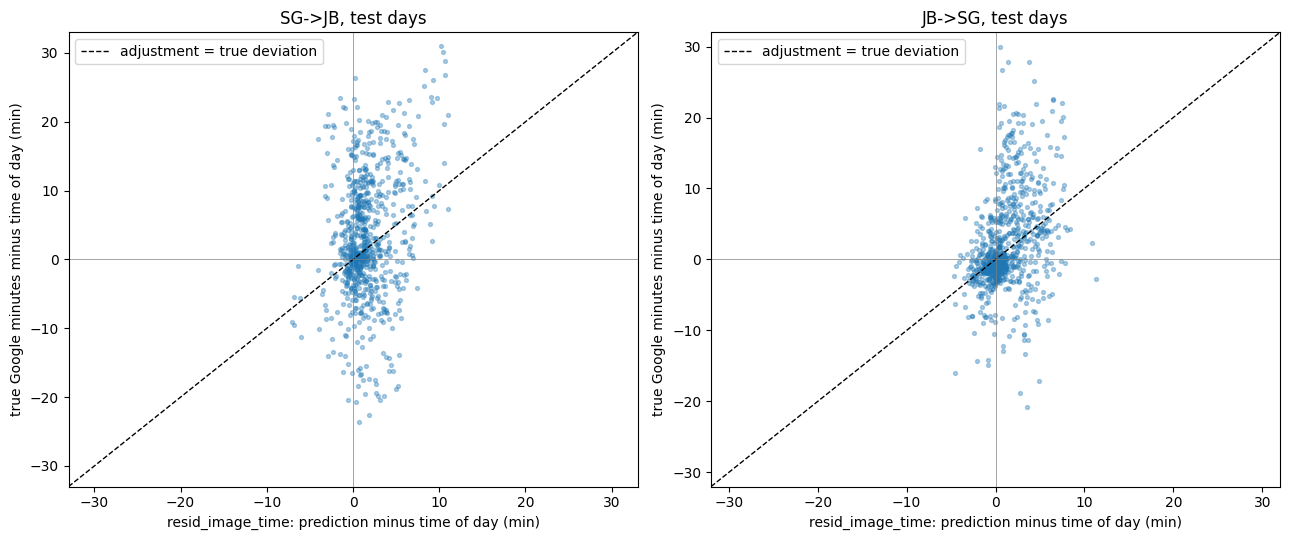

In [7]:
# Does the model's departure from the time-of-day baseline point the right way? For every variant and direction on the test
# days: the correlation between (prediction - baseline) and (true minutes - baseline), and the slope of the second on the
# first. 0 means the model adds nothing the clock does not already say; a slope near 1 means its adjustments are right-sized.
import matplotlib.pyplot as plt

def mean_pred(tag, d):
    return np.mean([preds_all[(tag, s)][d]["minutes"] for s in SEEDS], axis=0)      # seed-averaged minutes

rows = []
for tag in RUN:
    for d, (name, mcol, bcol) in enumerate(DIRS):
        base_min = tod_minutes(fit_df, test_eval, mcol)
        ok = test_eval[bcol].values >= 0
        adj, true_dev = (mean_pred(tag, d) - base_min)[ok], (test_eval[mcol].values - base_min)[ok]
        rows.append(dict(variant=tag, dir=name, adjustment_sd=adj.std(), correlation=np.corrcoef(adj, true_dev)[0, 1],
                         slope=np.polyfit(adj, true_dev, 1)[0] if adj.std() > 0 else np.nan))
print("Adjustment of each variant relative to time of day, test days (seed-averaged predictions)")
print(pd.DataFrame(rows).round(2).to_string(index=False))

for d, (name, mcol, bcol) in enumerate(DIRS):
    t_band, t_min = test_eval[bcol].values, test_eval[mcol].values
    tod = tod_minutes(fit_df, test_eval, mcol)
    table = []
    for b in range(N_BANDS):
        s = t_band == b
        if s.sum():
            table.append({"true band": BAND_LABELS[b], "n": int(s.sum()), "true min (mean)": t_min[s].mean(), "time of day": tod[s].mean(),
                          **{tag: mean_pred(tag, d)[s].mean() for tag in RUN}})
    print(f"\n{name}: mean predicted minutes by true band, test days")
    print(pd.DataFrame(table).round(1).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for d, (name, mcol, bcol) in enumerate(DIRS):
    tod = tod_minutes(fit_df, test_eval, mcol)
    true_dev, adj = test_eval[mcol].values - tod, mean_pred(best, d) - tod
    ax = axes[d]
    ax.scatter(adj, true_dev, s=8, alpha=0.35)
    lim = max(np.nanmax(np.abs(true_dev)), np.nanmax(np.abs(adj))) + 2
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="adjustment = true deviation")
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel=f"{best}: prediction minus time of day (min)",
           ylabel="true Google minutes minus time of day (min)", title=f"{name}, test days")
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Sample check
Test-day frames with the true Google minutes and the model's minutes: 6 random frames, the 6 biggest errors and the 6 longest real drive times. Set `CHECK_VARIANT` to look at another variant. `manual_QA_sample.csv` holds these frames; `detailed_test_predictions.csv` holds every test frame.

resid_image_time: loss residual, model input = FULL IMAGE


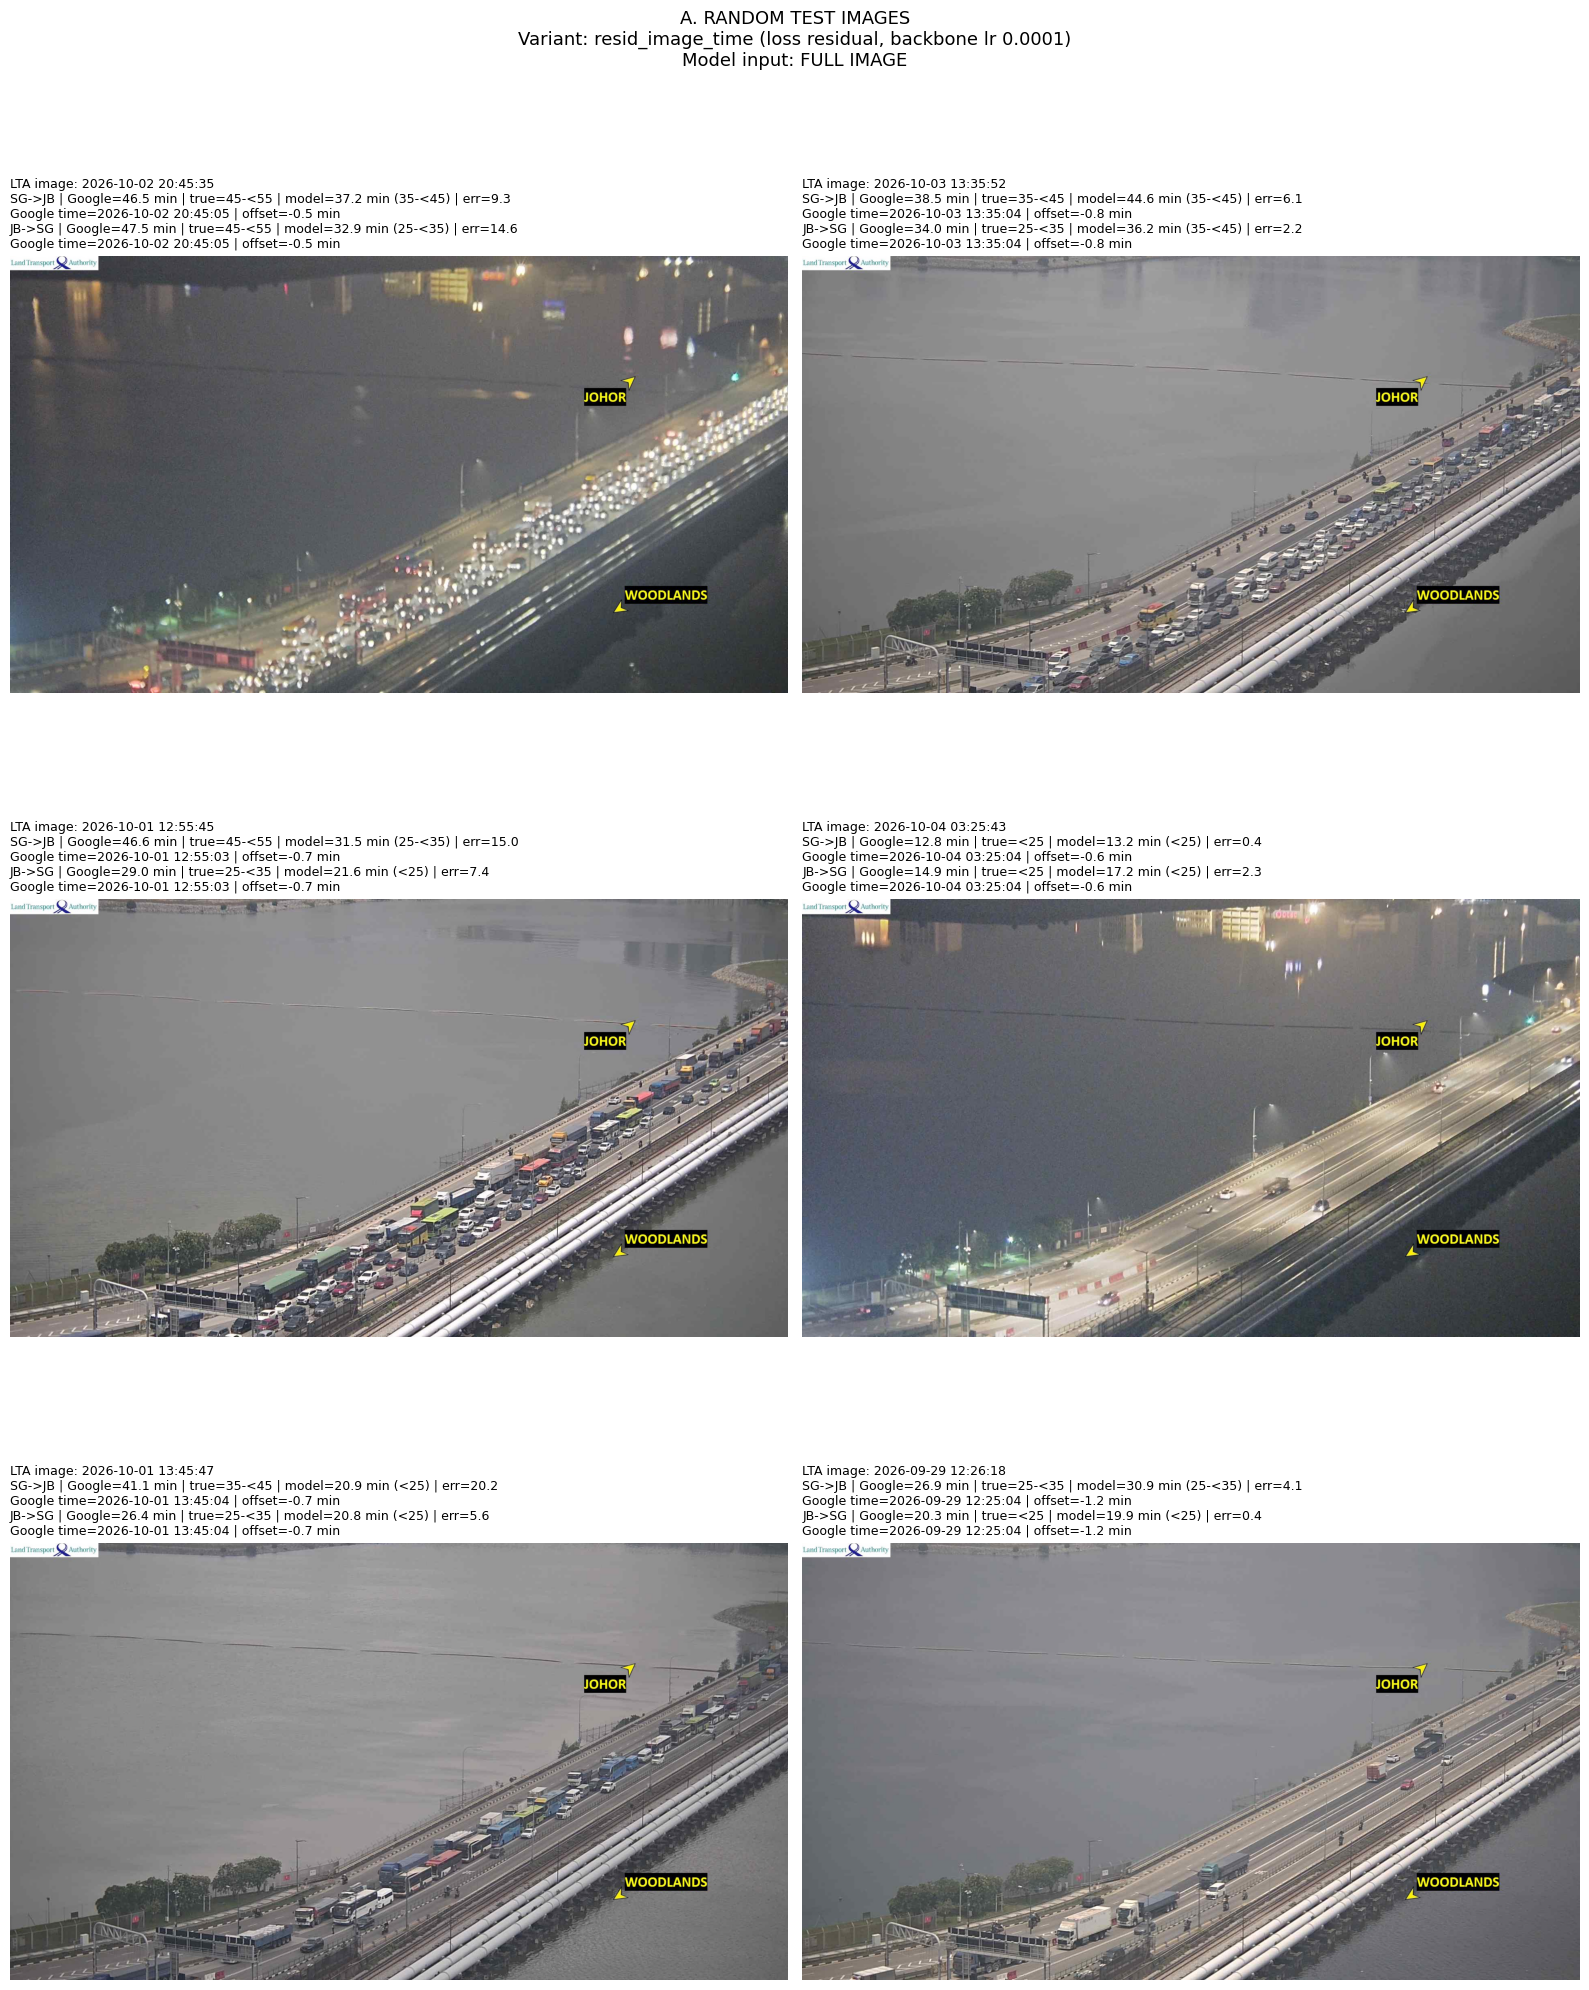

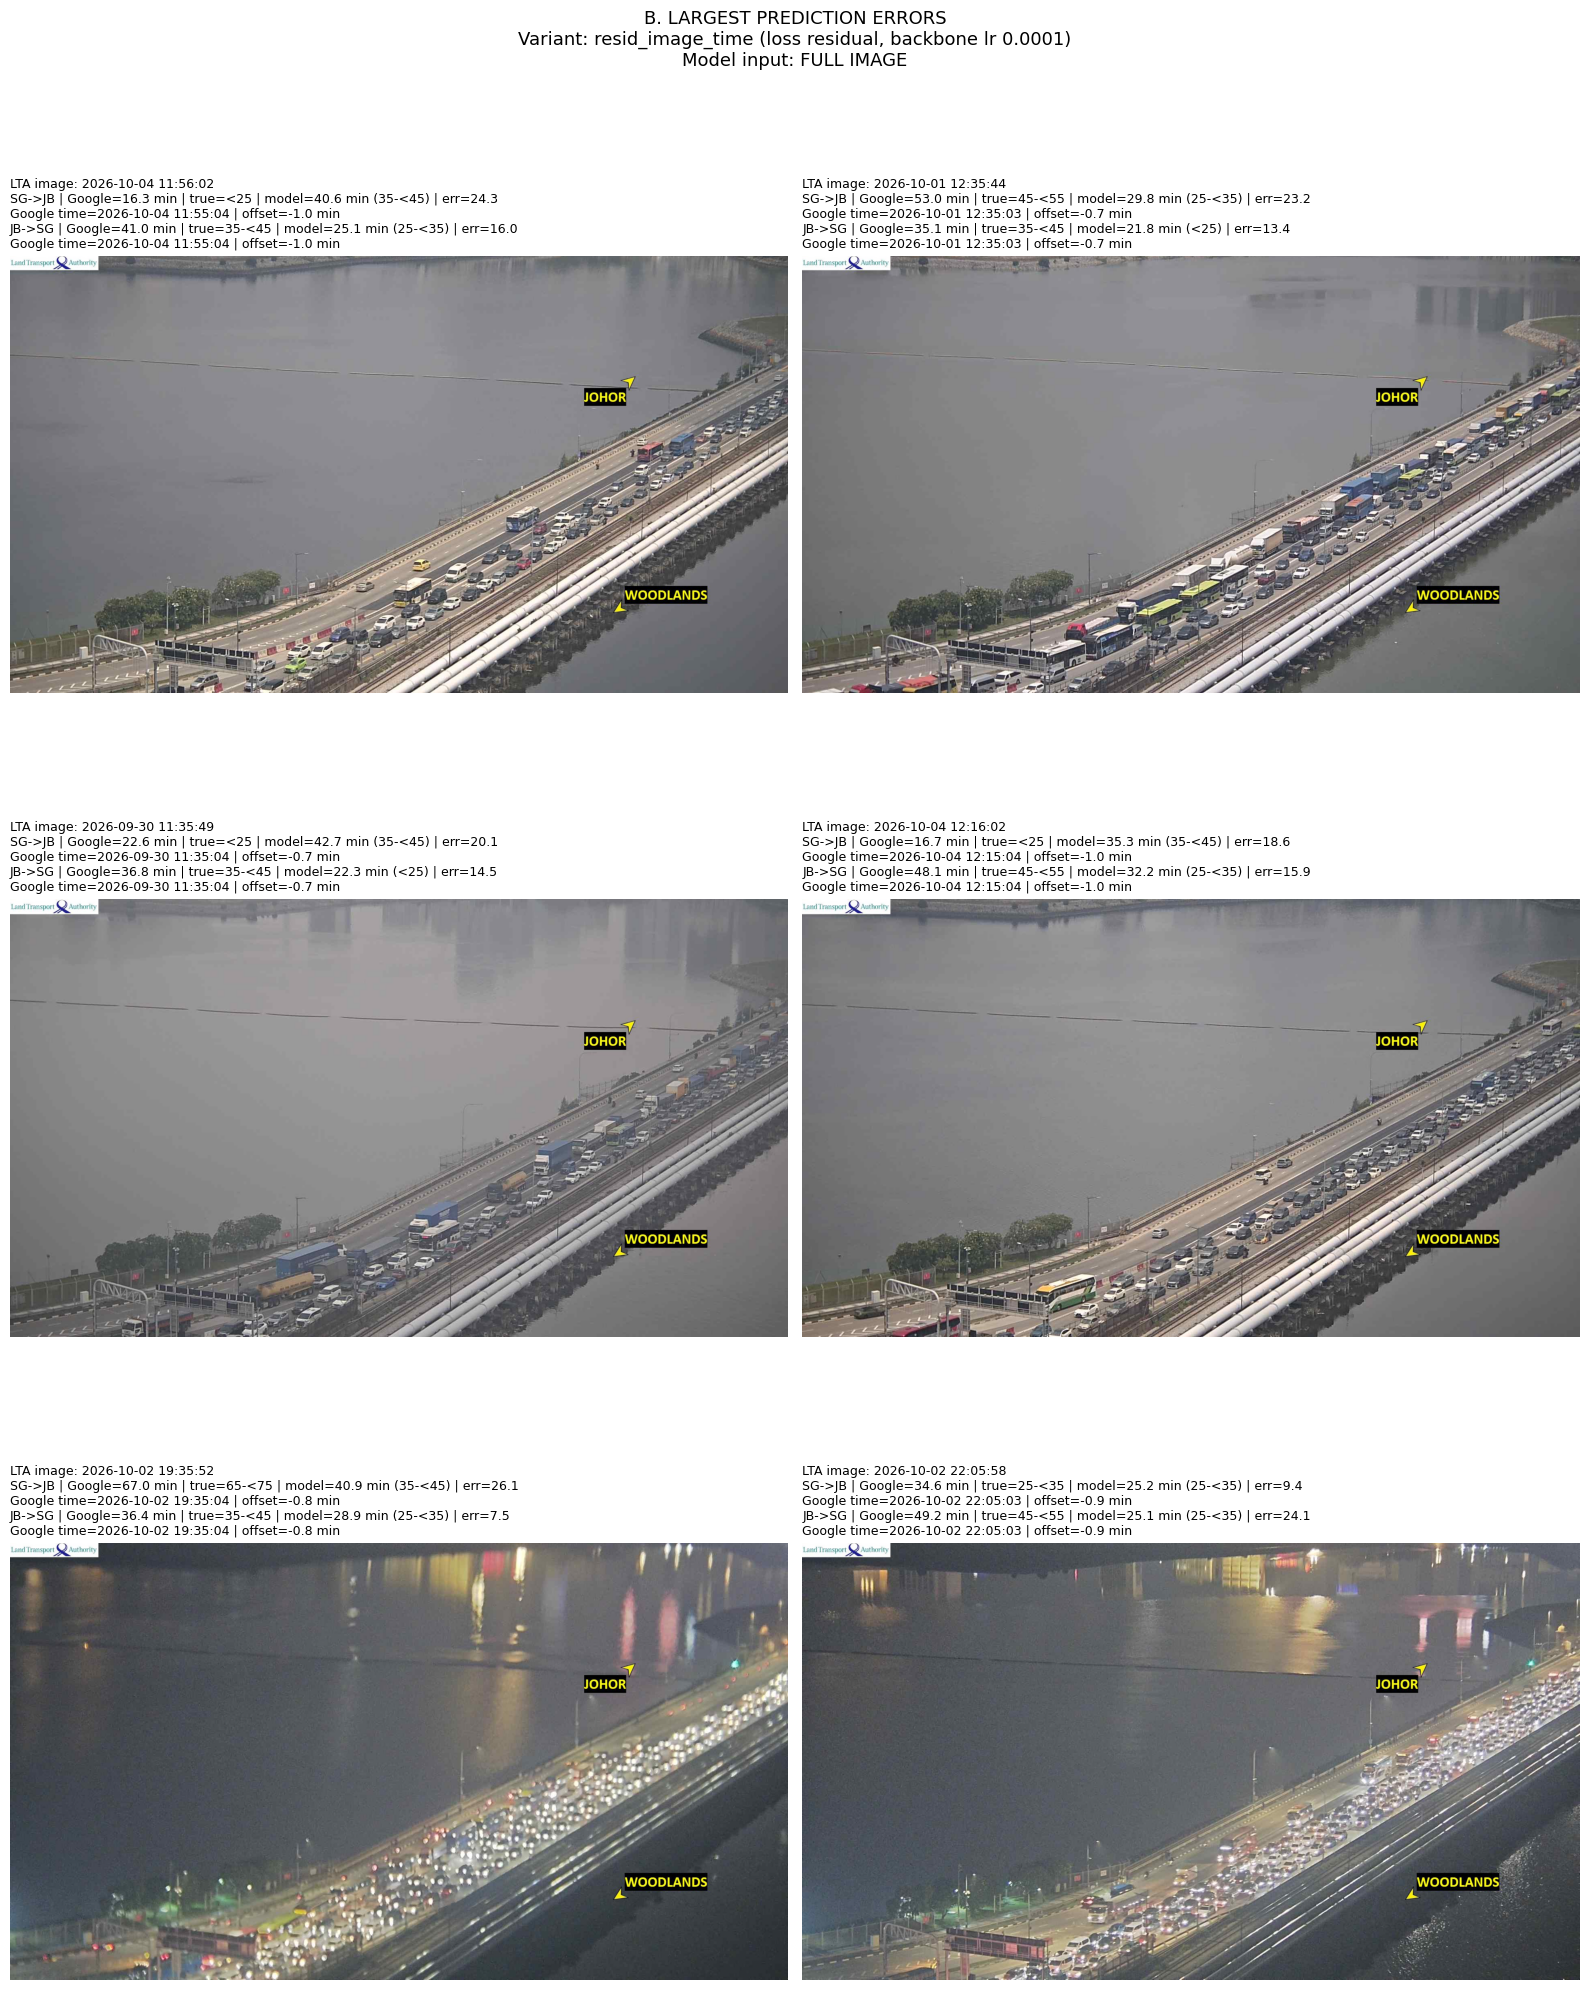

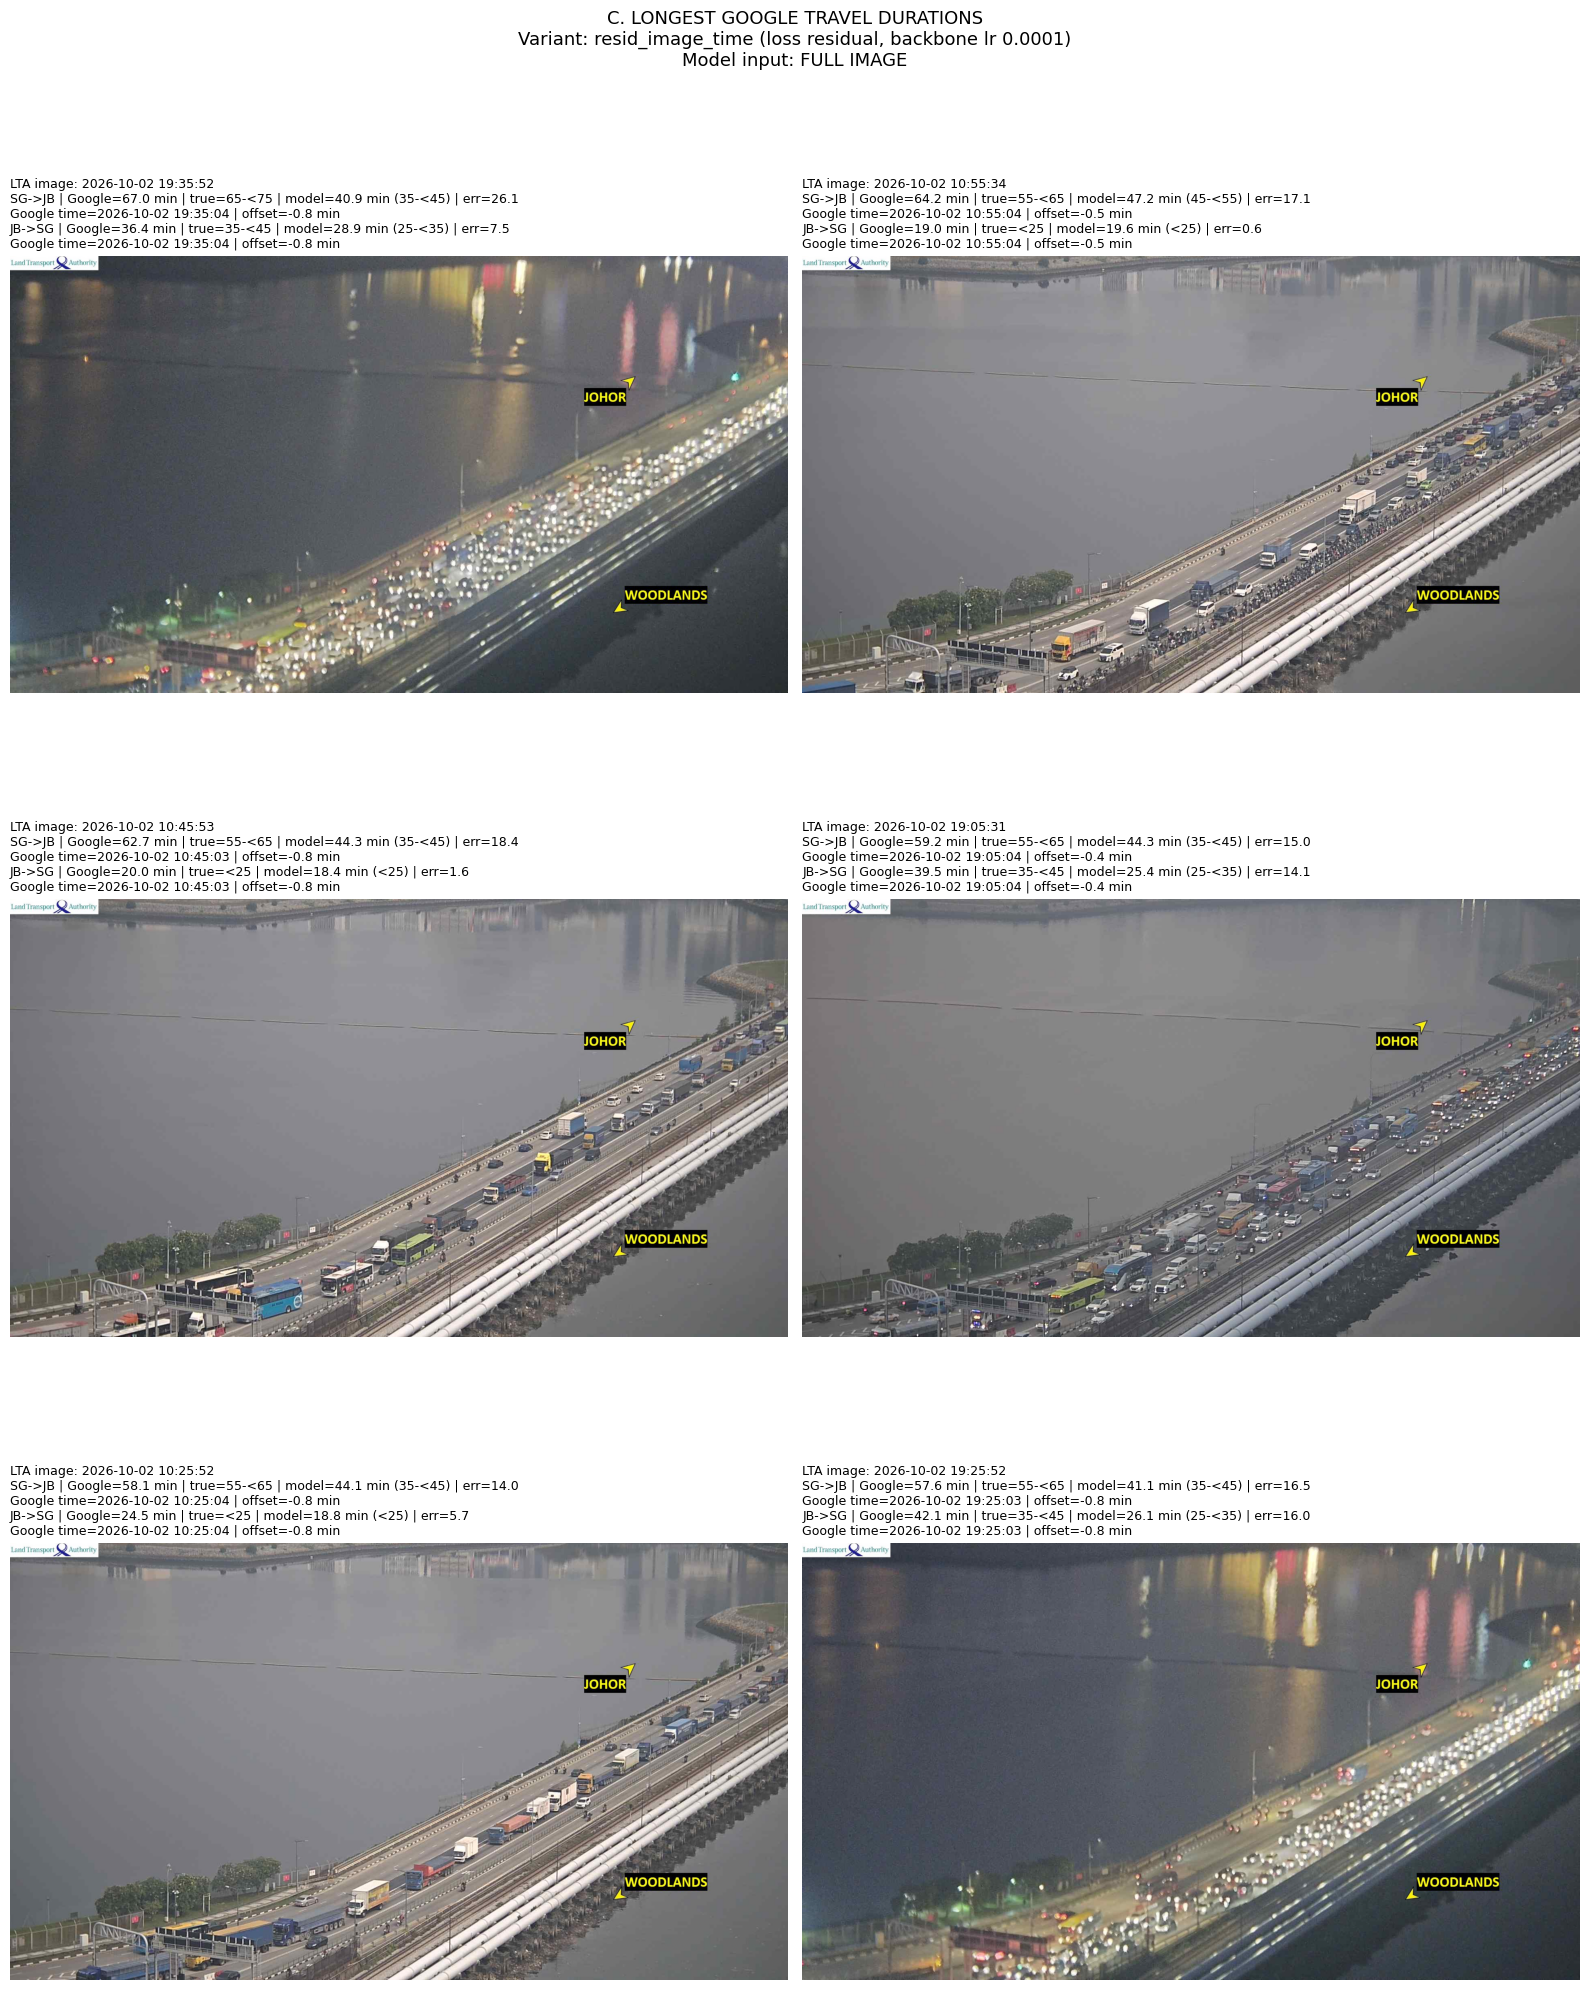


Manual QA sample: 17 unique frames


,ts,path,sg_jb_google_ts,sg_jb_align_offset_min,sg_jb_min,sg_jb_true_band,sg_jb_pred_band,sg_jb_model_min,sg_jb_abs_error_min,jb_sg_google_ts,jb_sg_align_offset_min,jb_sg_min,jb_sg_true_band,jb_sg_pred_band,jb_sg_model_min,jb_sg_abs_error_min,mean_abs_error_min
548,2026-10-02 20:45:35,/content/frames_2701/2701_20261002T204535.jpg,2026-10-02 20:45:05.704,-0.488,46.533,45-<55,35-<45,37.190,9.343,2026-10-02 20:45:05.704,-0.488,47.483,45-<55,25-<35,32.901,14.582,11.963
647,2026-10-03 13:35:52,/content/frames_2701/2701_20261003T133552.jpg,2026-10-03 13:35:04.241,-0.796,38.550,35-<45,35-<45,44.649,6.099,2026-10-03 13:35:04.241,-0.796,34.017,25-<35,35-<45,36.249,2.233,4.166
363,2026-10-01 12:55:45,/content/frames_2701/2701_20261001T125545.jpg,2026-10-01 12:55:03.867,-0.686,46.583,45-<55,25-<35,31.547,15.036,2026-10-01 12:55:03.867,-0.686,29.017,25-<35,<25,21.582,7.435,11.236
722,2026-10-04 03:25:43,/content/frames_2701/2701_20261004T032543.jpg,2026-10-04 03:25:04.137,-0.648,12.767,<25,<25,13.209,0.443,2026-10-04 03:25:04.137,-0.648,14.917,<25,<25,17.234,2.317,1.380
368,2026-10-01 13:45:47,/content/frames_2701/2701_20261001T134547.jpg,2026-10-01 13:45:04.248,-0.713,41.100,35-<45,<25,20.878,20.222,2026-10-01 13:45:04.248,-0.713,26.450,25-<35,<25,20.841,5.609,12.916
74,2026-09-29 12:26:18,/content/frames_2701/2701_20260929T122618.jpg,2026-09-29 12:25:04.062,-1.232,26.850,25-<35,25-<35,30.943,4.093,2026-09-29 12:25:04.062,-1.232,20.317,<25,<25,19.897,0.420,2.257
772,2026-10-04 11:56:02,/content/frames_2701/2701_20261004T115602.jpg,2026-10-04 11:55:04.248,-0.963,16.283,<25,35-<45,40.562,24.279,2026-10-04 11:55:04.248,-0.963,41.050,35-<45,25-<35,25.084,15.966,20.123
361,2026-10-01 12:35:44,/content/frames_2701/2701_20261001T123544.jpg,2026-10-01 12:35:03.951,-0.667,53.050,45-<55,25-<35,29.844,23.206,2026-10-01 12:35:03.951,-0.667,35.117,35-<45,<25,21.751,13.365,18.286
212,2026-09-30 11:35:49,/content/frames_2701/2701_20260930T113549.jpg,2026-09-30 11:35:04.208,-0.747,22.617,<25,35-<45,42.668,20.051,2026-09-30 11:35:04.208,-0.747,36.800,35-<45,<25,22.324,14.476,17.264
774,2026-10-04 12:16:02,/content/frames_2701/2701_20261004T121602.jpg,2026-10-04 12:15:04.198,-0.963,16.667,<25,35-<45,35.267,18.601,2026-10-04 12:15:04.198,-0.963,48.100,45-<55,25-<35,32.239,15.861,17.231



Saved: /content/manual_QA_sample.csv (17 frames), /content/detailed_test_predictions.csv (841 test frames)


In [8]:
import matplotlib.pyplot as plt

CHECK_VARIANT = best                     # or any tag in RUN
N_EACH = 6                               # frames per group below
check_cfg = VARIANTS[CHECK_VARIANT]
view = ("NO IMAGE INPUT (hour and weekday only; the frame is shown for reference)" if not check_cfg["use_image"] else "FULL IMAGE" if check_cfg["crop"] is None else "YELLOW BOX / CROPPED REGION") + "".join(
    f" + {label}" for key, label in (("mask", "off-road masking"), ("equalize", "luminance equalisation"), ("grayscale", "grayscale"))
    if check_cfg[key])
print(f"{CHECK_VARIANT}: loss {check_cfg['loss']}, model input = {view}")

# Seed-averaged minutes (and class probabilities, for the ce / ordinal losses) of the checked variant on the test frames.
check_min = [np.mean([preds_all[(CHECK_VARIANT, s)][d]["minutes"] for s in SEEDS], axis=0) for d in range(2)]
check_probs = [None if preds_all[(CHECK_VARIANT, SEEDS[0])][d]["probs"] is None
               else np.mean([preds_all[(CHECK_VARIANT, s)][d]["probs"] for s in SEEDS], axis=0) for d in range(2)]
sample = test_eval.copy()
for d, (name, mcol, bcol) in enumerate(DIRS):
    k = mcol[:-len("_min")]
    sample[f"{k}_model_min"] = check_min[d]
    sample[f"{k}_pred_band"] = [BAND_LABELS[i] for i in np.digitize(check_min[d], BAND_EDGES)]       # band of the minute estimate
    sample[f"{k}_abs_error_min"] = np.abs(check_min[d] - sample[mcol])
    sample[f"{k}_true_band"] = [BAND_LABELS[int(b)] if b >= 0 else "NA" for b in sample[bcol]]
    if check_probs[d] is not None:
        sample[f"{k}_pred_confidence"] = check_probs[d].max(1)
        for c, label in enumerate(BAND_NAMES):
            sample[f"{k}_P_{label.replace('+', 'plus')}"] = check_probs[d][:, c]
sample["mean_abs_error_min"] = sample[["sg_jb_abs_error_min", "jb_sg_abs_error_min"]].mean(axis=1)
sample["max_actual_duration"] = sample[["sg_jb_min", "jb_sg_min"]].max(axis=1)
sample.to_csv(f"{OUT_DIR}/detailed_test_predictions.csv", index=False)

fmt_num = lambda x: "NA" if pd.isna(x) else f"{float(x):.1f}"
fmt_ts = lambda x: "NA" if pd.isna(x) else pd.Timestamp(x).strftime("%Y-%m-%d %H:%M:%S")

def title(row):
    lines = [f"LTA image: {fmt_ts(row['ts'])}"]
    for name, mcol, _ in DIRS:
        k = mcol[:-len("_min")]
        lines += [f"{name} | Google={fmt_num(row[mcol])} min | true={row[k + '_true_band']} | model={fmt_num(row[k + '_model_min'])} min "
                  f"({row[k + '_pred_band']}) | err={fmt_num(row[k + '_abs_error_min'])}",
                  f"Google time={fmt_ts(row[k + '_google_ts'])} | offset={fmt_num(row[k + '_align_offset_min'])} min"]
    return "\n".join(lines)

def show(indices, group_title):
    indices = list(indices)
    if not indices:
        return
    nrows = math.ceil(len(indices) / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 7 * nrows), squeeze=False)
    axes = axes.reshape(-1)
    for ax, idx in zip(axes, indices):
        row = sample.iloc[idx]
        if not os.path.exists(row["path"]):
            ax.text(0.5, 0.5, f"IMAGE NOT FOUND\n{row['path']}", ha="center", va="center")
        else:
            img = Image.open(row["path"]).convert("RGB")
            W, H = img.size
            ax.imshow(img)
            if check_cfg["crop"] is not None:
                l, t, r, b = check_cfg["crop"]
                ax.add_patch(plt.Rectangle((l * W, t * H), (r - l) * W, (b - t) * H, fill=False, edgecolor="yellow", linewidth=2))
            ax.set_title(title(row), fontsize=9, loc="left")
            if all(p is not None for p in check_probs):
                probs_text = "\n\n".join(f"Probabilities {name}\n" + " | ".join(f"{lab}:{q:.2f}" for lab, q in zip(BAND_NAMES, check_probs[d][idx]))
                                         for d, (name, _, _) in enumerate(DIRS))
                ax.text(0.01, 0.01, probs_text, transform=ax.transAxes, fontsize=7, va="bottom", ha="left",
                        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
        ax.axis("off")
    for ax in axes[len(indices):]:
        ax.axis("off")
    fig.suptitle(f"{group_title}\nVariant: {CHECK_VARIANT} (loss {check_cfg['loss']}, backbone lr {check_cfg['lr_backbone']:g})\nModel input: {view}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

random_idx = np.random.default_rng(42).choice(len(sample), size=min(N_EACH, len(sample)), replace=False)
worst_idx = sample["mean_abs_error_min"].nlargest(N_EACH).index.tolist()
longest_idx = sample["max_actual_duration"].nlargest(N_EACH).index.tolist()
show(random_idx, "A. RANDOM TEST IMAGES")
show(worst_idx, "B. LARGEST PREDICTION ERRORS")
show(longest_idx, "C. LONGEST GOOGLE TRAVEL DURATIONS")

# The frames shown above, with alignment, truth, prediction and (where the loss gives them) the band probabilities, for manual checking.
qa = sample.iloc[list(dict.fromkeys(list(random_idx) + worst_idx + longest_idx))]
qa_cols = (["ts", "path"] + [f"{k}_{c}" for k in ("sg_jb", "jb_sg") for c in
           ("google_ts", "align_offset_min", "min", "true_band", "pred_band", "model_min", "abs_error_min")]
           + ["mean_abs_error_min"] + [c for c in qa.columns if "_P_" in c])
qa[qa_cols].to_csv(f"{OUT_DIR}/manual_QA_sample.csv", index=False)
print(f"\nManual QA sample: {len(qa)} unique frames")
display(qa[qa_cols].round({c: 3 for c in qa[qa_cols].select_dtypes("number").columns}))
print(f"\nSaved: {OUT_DIR}/manual_QA_sample.csv ({len(qa)} frames), {OUT_DIR}/detailed_test_predictions.csv ({len(sample):,} test frames)")
